# 01 — EDA & Labeling
## EV Charger Reliability Analytics

This notebook covers:
1. Raw data overview and labeling funnel
2. Class distribution
3. **Country-level non-operational rate table** (headline finding)
4. Status distribution breakdown
5. Connection / infrastructure feature distributions
6. Missing value analysis

> **Stop point**: Review the country-level non-op rate table in Section 3 before proceeding to modeling.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

# Make src importable from notebooks/
sys.path.insert(0, str(Path().resolve().parent))

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})
CMAP_DIV = "RdYlGn_r"
COLOR_OP  = "#2196F3"   # blue  to Operational
COLOR_NOP = "#F44336"   # red   to Non-Operational
COLOR_ZA  = "#FF6F00"   # amber to South Africa highlight

ROOT       = Path().resolve().parent
PROCESSED  = ROOT / "data" / "processed"
RAW        = ROOT / "data" / "raw"
FIG_DIR    = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Paths OK")


Paths OK


## 1. Labeling Funnel

Tracks record counts at each exclusion stage from the raw OCM pull to the
final labeled dataset. Each stage is logged by `src/label_target.py`.


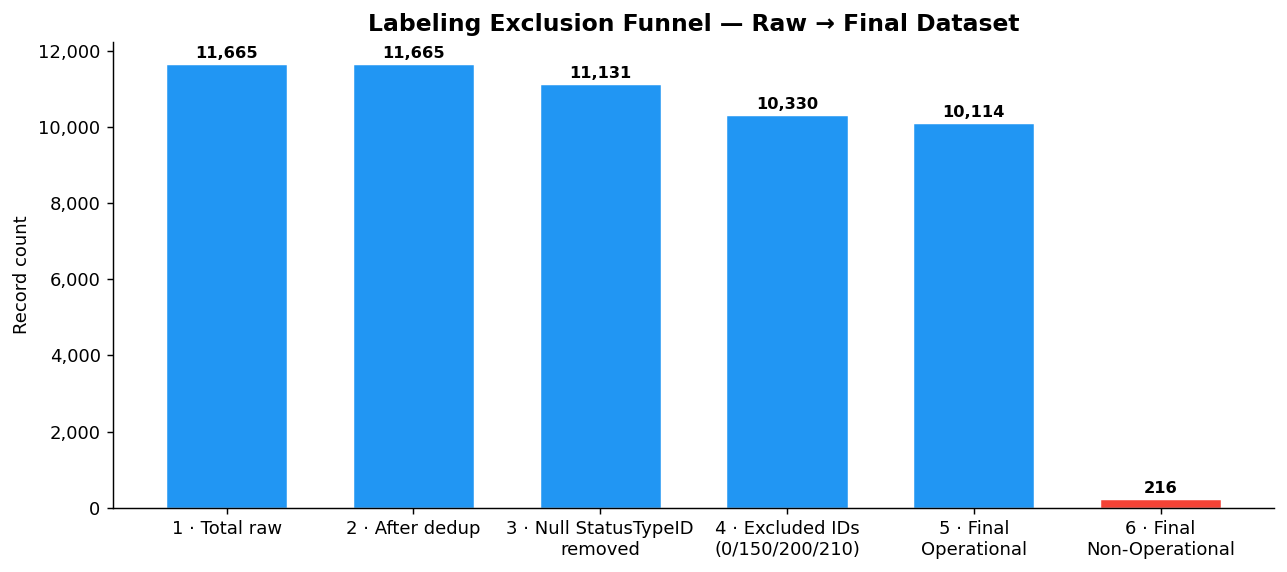

{
  "1_total_raw": 11665,
  "2_after_dedup": 11665,
  "3_after_removing_missing_status": 11131,
  "4_after_removing_excluded_ids": 10330,
  "5_final_operational": 10114,
  "6_final_non_operational": 216,
  "7_final_total": 10330
}


In [2]:
with open(PROCESSED / "labeling_funnel.json") as f:
    funnel = json.load(f)

labels = [
    "1 · Total raw",
    "2 · After dedup",
    "3 · Null StatusTypeID\nremoved",
    "4 · Excluded IDs\n(0/150/200/210)",
    "5 · Final\nOperational",
    "6 · Final\nNon-Operational",
]
values = [
    funnel["1_total_raw"],
    funnel["2_after_dedup"],
    funnel["3_after_removing_missing_status"],
    funnel["4_after_removing_excluded_ids"],
    funnel["5_final_operational"],
    funnel["6_final_non_operational"],
]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(labels, values,
              color=[COLOR_OP]*4 + [COLOR_OP, COLOR_NOP],
              edgecolor="white", linewidth=0.8, width=0.65)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f"{val:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Record count", fontsize=10)
ax.set_title("Labeling Exclusion Funnel — Raw to Final Dataset", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(FIG_DIR / "01_labeling_funnel.png", dpi=150)
plt.show()
print(json.dumps(funnel, indent=2))


**Exclusion rationale:**

| Stage | What's removed | Why |
|---|---|---|
| Null `StatusTypeID` | 534 records | No status recorded — treating as Unknown would mask data absence |
| ID 0 (Unknown) | 542 records | No reliable label signal; including would add noise |
| ID 150 (Planned) | 259 records | Station not yet built; infrastructure specs are speculative |
| IDs 200/210 (Removed) | 0 seen here | Decommissioned sites — "broken" ≠ "gone" |

**Note on ID 30 (Temporarily Unavailable):** Kept as *Operational*. OCM's own
`IsOperational` flag is `true` for this status — it represents a temporary
scheduling/access issue (e.g., site closed for maintenance window), not
equipment failure. See OCM API documentation.


## 2. Class Distribution

label
Operational        10114
Non-Operational      216
Name: count, dtype: int64

Class imbalance ratio: 46.8 : 1


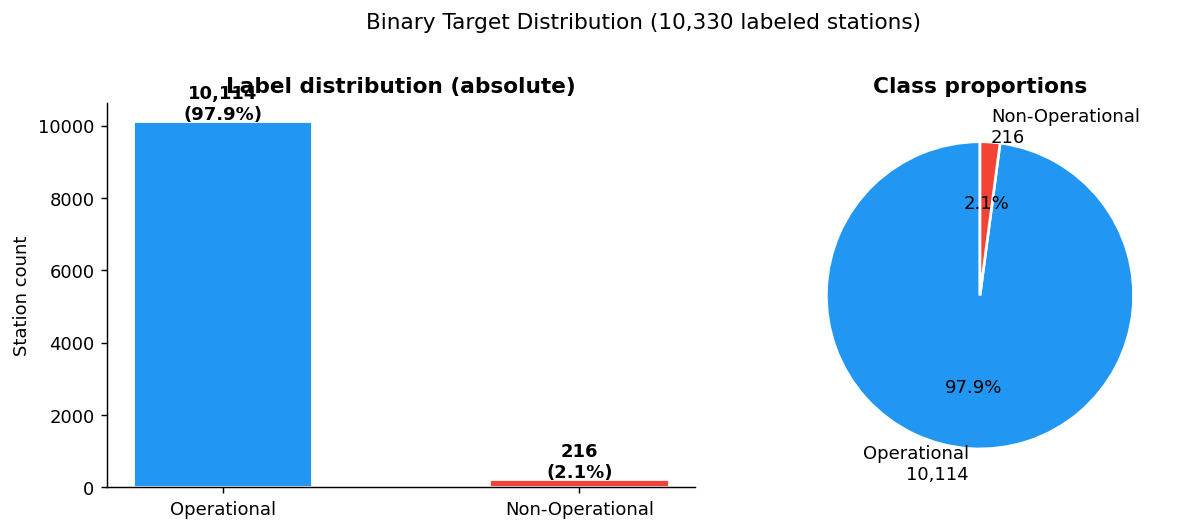

In [3]:
df = pd.read_csv(PROCESSED / "labeled_poi.csv", low_memory=False)
df["country"] = df["AddressInfo.Country.Title"].fillna("Unknown")
df["is_non_op"] = (df["label"] == "Non-Operational").astype(int)

label_counts = df["label"].value_counts()
print(label_counts)
print(f"\nClass imbalance ratio: {label_counts['Operational'] / label_counts['Non-Operational']:.1f} : 1")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
ax1.bar(label_counts.index, label_counts.values,
        color=[COLOR_OP, COLOR_NOP], edgecolor="white", width=0.5)
for i, (lbl, val) in enumerate(label_counts.items()):
    ax1.text(i, val + 60, f"{val:,}\n({val/len(df)*100:.1f}%)",
             ha="center", fontsize=10, fontweight="bold")
ax1.set_title("Label distribution (absolute)", fontweight="bold")
ax1.set_ylabel("Station count")

# Pie
ax2.pie(label_counts.values,
        labels=[f"{l}\n{v:,}" for l, v in label_counts.items()],
        colors=[COLOR_OP, COLOR_NOP],
        autopct="%1.1f%%", startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax2.set_title("Class proportions", fontweight="bold")

plt.suptitle("Binary Target Distribution (10,330 labeled stations)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_class_distribution.png", dpi=150)
plt.show()


## 3. Country-Level Non-Operational Rate

> **Headline finding**: South Africa's non-operational rate is **29.1%** — 
> more than **5× the next-highest country** (Denmark at 5.4%) and **~40× the 
> global median (~0.7%)**.


In [4]:
country_stats = (
    df.groupby("country")
    .agg(total=("label", "count"), non_op=("is_non_op", "sum"))
    .reset_index()
)
country_stats["non_op_rate_pct"] = (
    country_stats["non_op"] / country_stats["total"] * 100
).round(1)
country_stats = country_stats.sort_values("non_op_rate_pct", ascending=False).reset_index(drop=True)

# ── Display formatted table ──────────────────────────────────────────────
def flag(country):
    return "⚠️" if country == "South Africa" else ""

display_df = country_stats.copy()
display_df["non_op_rate_pct"] = display_df["non_op_rate_pct"].apply(lambda x: f"{x:.1f}%")
display_df["Flag"] = display_df["country"].apply(flag)
display_df = display_df.rename(columns={
    "country": "Country",
    "total": "Total stations",
    "non_op": "Non-Operational",
    "non_op_rate_pct": "Non-Op Rate",
})
display_df = display_df[["Country", "Total stations", "Non-Operational", "Non-Op Rate", "Flag"]]

print("Country-level Non-Operational Rate Table")
print("=" * 62)
print(display_df.to_string(index=False))


Country-level Non-Operational Rate Table
           Country  Total stations  Non-Operational Non-Op Rate Flag
      South Africa             492              143       29.1%   ⚠️
           Denmark             390               21        5.4%     
          Portugal             483               11        2.3%     
             India             500               10        2.0%     
    United Kingdom             486                6        1.2%     
            Poland             484                6        1.2%     
           Ireland             373                4        1.1%     
             Italy             496                5        1.0%     
       Netherlands             497                4        0.8%     
           Belgium             497                3        0.6%     
             Spain             470                2        0.4%     
            Canada             487                1        0.2%     
         Australia             491                0        0.0

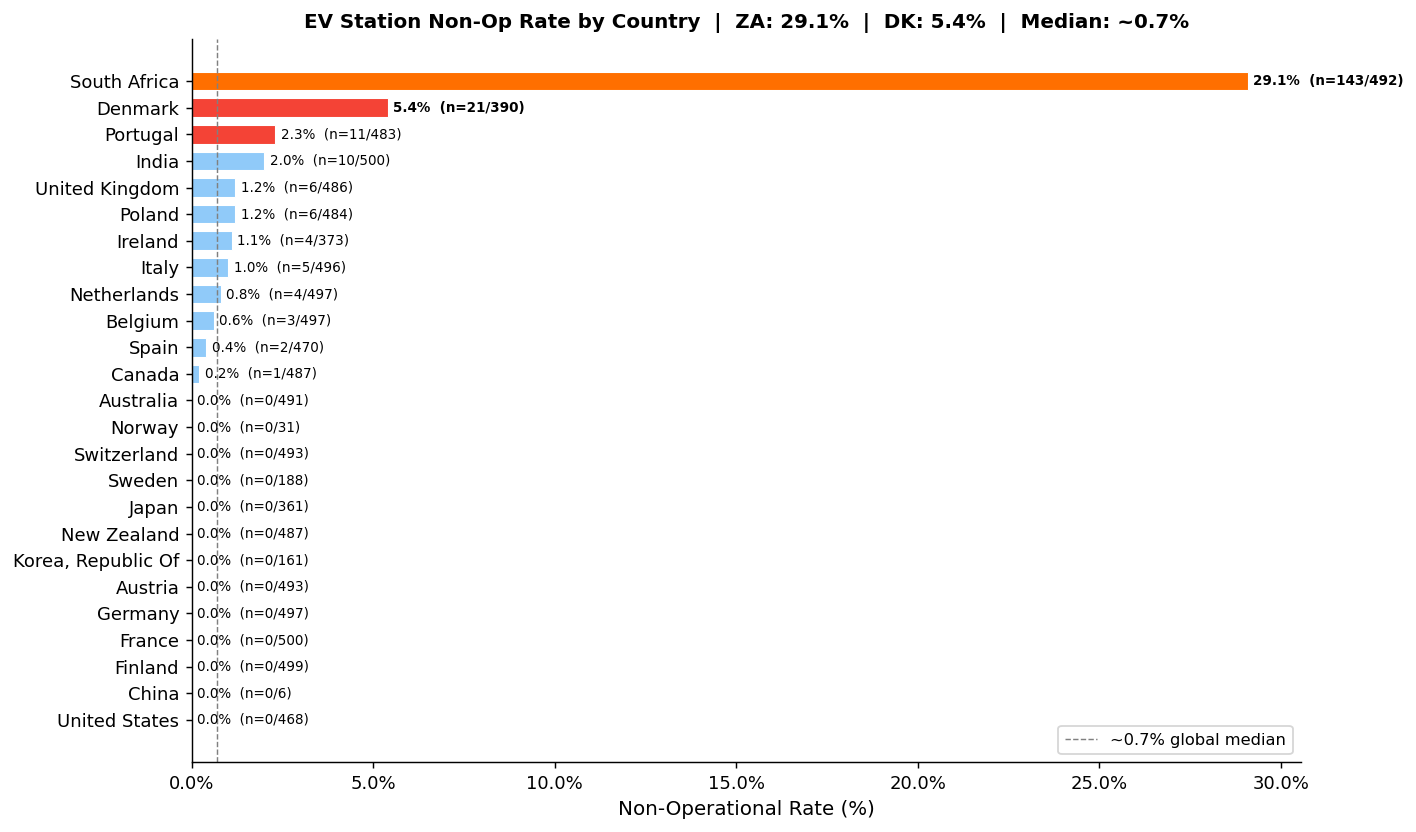

In [5]:
# ── Visualise ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6.5))

bar_colors = [
    COLOR_ZA if c == "South Africa" else COLOR_NOP
    if r > 2 else "#90CAF9"
    for c, r in zip(country_stats["country"], country_stats["non_op_rate_pct"])
]

bars = ax.barh(
    country_stats["country"],
    country_stats["non_op_rate_pct"],
    color=bar_colors, edgecolor="white", linewidth=0.6, height=0.7
)

# Annotate each bar
for bar, (_, row) in zip(bars, country_stats.iterrows()):
    rate = row["non_op_rate_pct"]
    label_str = f"{rate:.1f}%  (n={int(row['non_op'])}/{int(row['total'])})"
    ax.text(
        rate + 0.15, bar.get_y() + bar.get_height() / 2,
        label_str, va="center", fontsize=7.5,
        color="black" if rate < 20 else "black", fontweight="bold" if rate > 5 else "normal"
    )

ax.axvline(x=0.7, color="grey", linestyle="--", linewidth=0.8, label="~0.7% global median")
ax.set_xlabel("Non-Operational Rate (%)", fontsize=11)
ax.set_title("EV Station Non-Op Rate by Country  |  ZA: 29.1%  |  DK: 5.4%  |  Median: ~0.7%",
    fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig(FIG_DIR / "03_country_nonop_rate.png", dpi=150, bbox_inches="tight")
plt.show()


### ⚠️ Headline Finding: South Africa (29.1% Non-Operational Rate)

South Africa's non-operational rate of **29.1%** (143 out of 492 stations) is a dramatic
outlier compared to the rest of the dataset:

| Tier | Countries | Typical non-op rate |
|---|---|---|
| **Critical outlier** | 🇿🇦 South Africa | **29.1%** |
| Elevated | 🇩🇰 Denmark | 5.4% |
| Moderate | 🇵🇹 Portugal, 🇮🇳 India, 🇬🇧 UK | 1.2–2.3% |
| Low / None | All others | 0–0.8% |

#### Likely causal context: Load-shedding

South Africa experiences **"load-shedding"** — scheduled, rotating power cuts implemented
by the national utility Eskom to manage supply shortfalls. These cuts occur across all
eight "stages," ranging from Stage 1 (2 hours off per day) to Stage 8 (12–16 hours off
per day). During load-shedding, EV chargers:

1. **Go offline during the outage** — their OCM status is reported as Non-Operational
2. **May have degraded hardware** from repeated power cycling (voltage fluctuations at
   restoration cause inverter and EVSE controller stress)
3. **May not update status automatically** if their connectivity module also loses power,
   leaving stale "Non-Operational" records

South Africa experienced [record Stage 6 load-shedding throughout 2022–2023](https://en.wikipedia.org/wiki/South_African_energy_crisis),
with some periods exceeding 200+ days of continuous rotational cuts. The OCM data
collection period likely overlaps with this peak, explaining the extreme non-op rate.

#### Modeling implication

**South Africa is a confounder, not a generalizable infrastructure signal.** If
`country_iso` is included as a feature, the model will learn "South Africa → Non-Op"
as a near-deterministic rule — capturing *grid infrastructure* rather than
*charging hardware* quality. This is precisely why we run the **dual RF experiment**
(with and without country) in Notebook 03 to test whether infrastructure features
carry independent signal.


## 4. StatusTypeID Distribution in Raw Data

                    Status  Count  Pct
               Operational  10071 86.3
                   Unknown    542  4.6
              NULL/Missing    534  4.6
   Planned For Future Date    259  2.2
           Not Operational    216  1.9
   Temporarily Unavailable     25  0.2
Partly Operational (Mixed)     18  0.2


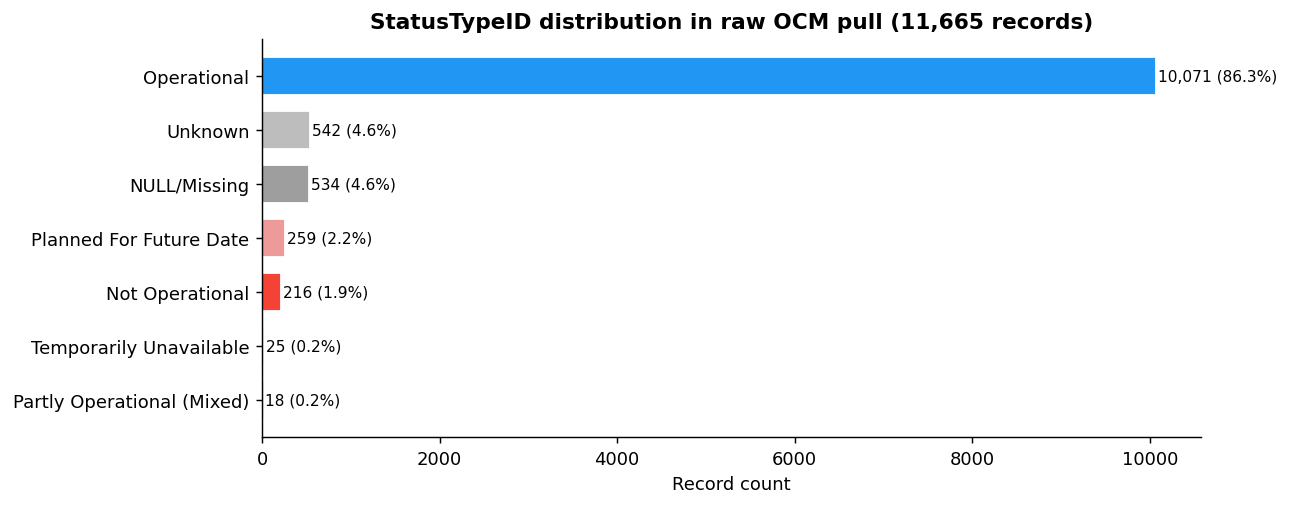

In [6]:
with open(RAW / "reference_status_types.json") as f:
    status_ref = {int(s["ID"]): s["Title"] for s in json.load(f)}

# Reload raw to see full status distribution (including excluded)
import json as _json
with open(RAW / "raw_poi_all.json") as f:
    raw = _json.load(f)

raw_df = pd.json_normalize(raw, sep=".")
sid_col = "StatusType.ID"
raw_df["status_id"] = pd.to_numeric(raw_df[sid_col], errors="coerce")
raw_df["status_title"] = raw_df["status_id"].map(
    lambda x: status_ref.get(int(x), "Unknown") if pd.notna(x) else "NULL/Missing"
)

status_dist = raw_df["status_title"].value_counts().reset_index()
status_dist.columns = ["Status", "Count"]
status_dist["Pct"] = (status_dist["Count"] / len(raw_df) * 100).round(1)
print(status_dist.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
palette = {
    "Operational": COLOR_OP,
    "Currently Available (Automated Status)": "#42A5F5",
    "Currently In Use (Automated Status)": "#1565C0",
    "Temporarily Unavailable": "#FFA726",
    "Partly Operational (Mixed)": "#26A69A",
    "Not Operational": COLOR_NOP,
    "Unknown": "#BDBDBD",
    "Planned For Future Date": "#EF9A9A",
    "Removed (Decommissioned)": "#D32F2F",
    "Removed (Duplicate Listing)": "#B71C1C",
    "NULL/Missing": "#9E9E9E",
}
colors = [palette.get(s, "#BDBDBD") for s in status_dist["Status"]]
ax.barh(status_dist["Status"], status_dist["Count"],
        color=colors, edgecolor="white", height=0.7)
for i, (_, row) in enumerate(status_dist.iterrows()):
    ax.text(row["Count"] + 20, i, f'{row["Count"]:,} ({row["Pct"]:.1f}%)',
            va="center", fontsize=8.5)
ax.set_xlabel("Record count")
ax.set_title("StatusTypeID distribution in raw OCM pull (11,665 records)", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "04_status_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Infrastructure Feature Distributions

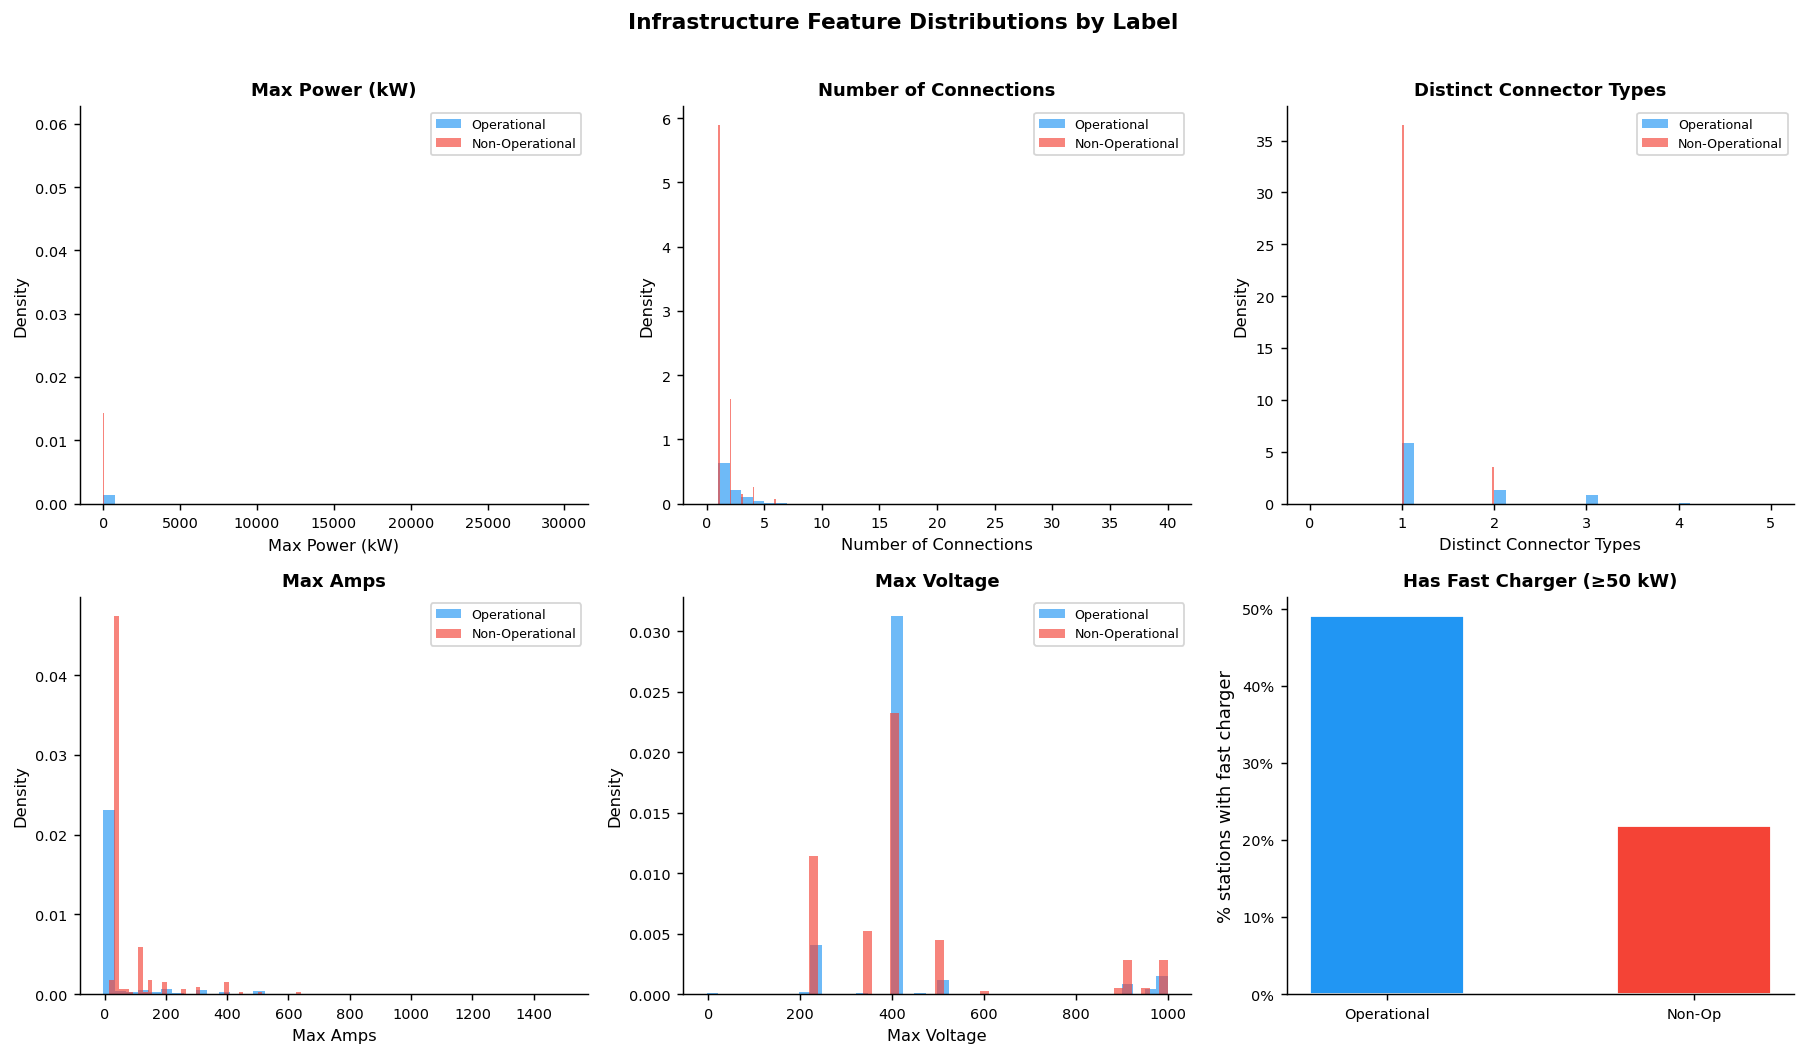

In [7]:
feat_with = pd.read_csv(PROCESSED / "features_with_country.csv")
target    = pd.read_csv(PROCESSED / "target.csv").squeeze()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

conn_features = [
    ("max_power_kw",               "Max Power (kW)"),
    ("n_connections",              "Number of Connections"),
    ("n_distinct_connection_types","Distinct Connector Types"),
    ("max_amps",                   "Max Amps"),
    ("max_voltage",                "Max Voltage"),
    ("has_fast_charger",           "Has Fast Charger (≥50 kW)"),
]

for ax, (col, title) in zip(axes, conn_features):
    if col not in feat_with.columns:
        ax.set_visible(False)
        continue
    op_vals  = feat_with.loc[target == 1, col].dropna()
    nop_vals = feat_with.loc[target == 0, col].dropna()
    if col == "has_fast_charger":
        vals = [
            [op_vals.mean()*100, nop_vals.mean()*100],
        ]
        ax.bar(["Operational", "Non-Op"], [op_vals.mean()*100, nop_vals.mean()*100],
               color=[COLOR_OP, COLOR_NOP], width=0.5, edgecolor="white")
        ax.set_ylabel("% stations with fast charger")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    else:
        ax.hist(op_vals,  bins=40, alpha=0.65, color=COLOR_OP,  label="Operational",     density=True)
        ax.hist(nop_vals, bins=40, alpha=0.65, color=COLOR_NOP, label="Non-Operational", density=True)
        ax.legend(fontsize=7)
        ax.set_xlabel(title, fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=8)

plt.suptitle("Infrastructure Feature Distributions by Label", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Missing Value Analysis (Feature Matrix)

In [8]:
missing = feat_with.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
print(f"Features with missing values: {len(missing)}")
print(missing.apply(lambda x: f'{x:.1f}%').to_string())

if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.4)))
    missing.plot(kind="barh", ax=ax, color="#EF9A9A", edgecolor="white")
    ax.set_xlabel("Missing %")
    ax.set_title("Missing Value Rates — Feature Matrix", fontweight="bold")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    plt.tight_layout()
    plt.savefig(FIG_DIR / "06_missing_values.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No missing values in feature matrix after imputation ✓")


Features with missing values: 0
Series([], )
No missing values in feature matrix after imputation ✓


## 7. EDA Summary & Next Steps

### Key findings

| Finding | Value | Implication |
|---|---|---|
| Total labeled stations | 10,330 | Sufficient for CV, thin for Non-Op class |
| Class imbalance | 46.8 : 1 | Must use `class_weight='balanced'` + recall/F1, not accuracy |
| South Africa non-op rate | **29.1%** | Grid-level confounder → dual RF run (with/without country) |
| Denmark non-op rate | 5.4% | Next outlier; possible data quality issue |
| Countries with 0 non-op | 14 / 25 | Many countries contribute no negative class signal |
| Non-Operational stations total | 216 | → Use stratified 5-fold CV, not single split |

### Before modeling (Steps 1–2 complete ✓)

- [x] **Step 1**: `Connections` column flattened with `ast.literal_eval()` → 9 new features
- [x] **Step 2**: Country-level non-op rate table built; South Africa 29.1% documented

### Proceed to modeling only after reviewing this table ↑

Next: `02_preprocessing_and_features.ipynb` → feature engineering detail  
Then: `03_modeling_and_evaluation.ipynb` → dual RF runs + stratified 5-fold CV
